# 3CSD Group 8 Random Split Implementation

**Random-split comparison notebook for Logistic Regression, CART, XGBoost, and a Feedforward Neural Network on the Global Terrorism Database**

This notebook is an exploratory copy of the main implementation. The modeling pipeline is kept the same, but the train/validation/test partitions use a stratified random split instead of the temporal split. Use it to compare random-split performance against the main temporal-split results.


## 1. Setup and Reproducibility

The notebook can be run from the project root or from `notebooks/`. The 2021 supplement is mandatory because the GTD provider distributes it separately.

Caching note: the first full run reads the Excel workbooks and writes `data/processed/gtd_combined_cleaned.parquet`. Later runs load this cache, avoiding repeated slow Excel parsing. Set `REBUILD_DATA_CACHE = True` only when the raw files change.


In [1]:
from pathlib import Path
import random
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.gtd_pipeline import *

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

USE_SAMPLE = False          # True = quick smoke test, False = final manuscript run.
SAMPLE_NROWS = 5000
REBUILD_DATA_CACHE = False  # True only if raw files changed.
USE_GPU = True
RUN_SHAP = True             # XGBoost stuff
SHAP_SAMPLE_SIZE = 1500

paths = get_project_paths(PROJECT_ROOT)

# Keep random-split outputs separate so they do not overwrite the manuscript-facing temporal-split run.
EXPERIMENT_NAME = "random_split"
paths.models_dir = paths.models_dir / EXPERIMENT_NAME
paths.figures_dir = paths.figures_dir / EXPERIMENT_NAME
paths.tables_dir = paths.tables_dir / EXPERIMENT_NAME
for d in [paths.models_dir, paths.figures_dir, paths.tables_dir]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", paths.root)
print("Raw data directory:", paths.raw_dir)
print("Main GTD file:", paths.main_file)
print("Mandatory 2021 supplement:", paths.supplement_2021_file)
print("Processed cache:", paths.cache_file)
print("Random-split models directory:", paths.models_dir)
print("Random-split figures directory:", paths.figures_dir)
print("Random-split tables directory:", paths.tables_dir)

Project root: c:\Documents\Compsci\CSELEC2C\Project
Raw data directory: c:\Documents\Compsci\CSELEC2C\Project\data\raw
Main GTD file: c:\Documents\Compsci\CSELEC2C\Project\data\raw\globalterrorismdb_0522dist.xlsx
Mandatory 2021 supplement: c:\Documents\Compsci\CSELEC2C\Project\data\raw\globalterrorismdb_2021Jan-June_1222dist.xlsx
Processed cache: c:\Documents\Compsci\CSELEC2C\Project\data\processed\gtd_combined_cleaned.parquet
Random-split models directory: c:\Documents\Compsci\CSELEC2C\Project\models\random_split
Random-split figures directory: c:\Documents\Compsci\CSELEC2C\Project\results\figures\random_split
Random-split tables directory: c:\Documents\Compsci\CSELEC2C\Project\results\tables\random_split


## 2. Modeling Assumptions and Feature Set

The target is GTD `success`. To reduce target leakage, casualty, property-damage, ransom, and hostage-outcome fields are excluded because they are consequences or post-event descriptors. The retained features are temporal, geopolitical, tactical, target, weapon, uncertainty, and claim-related fields.


In [2]:
print("Target:", TARGET)
print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print("Excluded leakage columns:", LEAKAGE_COLUMNS_EXCLUDED)

Target: success
Numeric features: ['iyear', 'imonth', 'iday', 'extended', 'latitude', 'longitude', 'specificity', 'vicinity', 'doubtterr', 'multiple', 'suicide', 'guncertain1', 'individual', 'claimed', 'INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY']
Categorical features: ['region_txt', 'country_txt', 'attacktype1_txt', 'targtype1_txt', 'targsubtype1_txt', 'natlty1_txt', 'weaptype1_txt', 'weapsubtype1_txt']
Excluded leakage columns: ['nkill', 'nkillus', 'nkillter', 'nwound', 'nwoundus', 'nwoundte', 'property', 'propextent', 'propextent_txt', 'propvalue', 'ransom', 'ransomamt', 'ransompaid', 'hostkidoutcome', 'hostkidoutcome_txt', 'nreleased']


## 3. Load, Clean, Cache, and Randomly Split Data

Both GTD files are mandatory. The main file and the 2021 supplement are combined, deduplicated by `eventid`, cleaned, then split using a stratified random design:

- Train: 70%
- Validation: 15%
- Test: 15%

This notebook is only for comparison against the main temporal-split implementation. Random splits usually look better because events from similar time periods can appear in train, validation, and test sets.



In [3]:
sample_nrows = SAMPLE_NROWS if USE_SAMPLE else None
if REBUILD_DATA_CACHE and paths.cache_file.exists():
    paths.cache_file.unlink()

df = load_gtd(paths, use_cache=not REBUILD_DATA_CACHE, sample_nrows=sample_nrows)
X, y, numeric_features, categorical_features = make_xy(df)

# Stratified random split: 70% train, 15% validation, 15% test.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_valid), len(X_test)],
    "start_year": [int(X_train.iyear.min()), int(X_valid.iyear.min()), int(X_test.iyear.min())],
    "end_year": [int(X_train.iyear.max()), int(X_valid.iyear.max()), int(X_test.iyear.max())],
    "success_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
})

class_balance = y.value_counts(normalize=True).rename("proportion").to_frame()
class_balance["count"] = y.value_counts()

print("Raw/cleaned shape:", df.shape)
print("Year range:", int(df.iyear.min()), "to", int(df.iyear.max()))
print("Split mode: stratified random split")
display(split_summary)
display(class_balance)

Raw/cleaned shape: (214666, 29)
Year range: 1970 to 2021
Split mode: stratified random split


,split,n,start_year,end_year,success_rate
0,train,150266,1970,2021,0.882888
1,validation,32200,1970,2021,0.882888
2,test,32200,1970,2021,0.882888


,proportion,count
success,,
1,0.882888,189526
0,0.117112,25140


## 4. Train Proposal Models

The model lineup includes Logistic Regression as the linear baseline, **CART** as a single decision-tree baseline, XGBoost as the stronger boosted-tree model, and a Feedforward Neural Network as the nonlinear dense architecture. CART is more appropriate here than the experimental tabular CNN because the GTD feature matrix is structured/tabular rather than spatial or sequential.



In [4]:
from sklearn.tree import DecisionTreeClassifier

models = build_models(numeric_features, categorical_features, y_train, use_gpu=USE_GPU, random_state=RANDOM_STATE)

# CART = Classification and Regression Tree. We add it as a single-tree baseline.
# The tree is depth-limited to reduce overfitting and class-weighted to address imbalance.
models["cart_decision_tree"] = Pipeline([
    ("preprocessor", make_preprocessor(numeric_features, categorical_features)),
    ("model", DecisionTreeClassifier(
        criterion="gini",
        max_depth=12,
        min_samples_leaf=100,
        min_samples_split=250,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

# Reorder for cleaner reporting: linear baseline, single tree, boosted trees, neural network.
ordered_model_names = ["logistic_regression", "cart_decision_tree", "xgboost", "feedforward_torch_nn"]
models = {name: models[name] for name in ordered_model_names if name in models}

models = train_models(models, X_train, y_train, paths)
print("Trained models:", list(models))

Training logistic_regression...
Training cart_decision_tree...
Training xgboost...
Training feedforward_torch_nn...
Torch NN epoch 01 | train_loss=0.1247 | valid_loss=0.1122
Torch NN epoch 05 | train_loss=0.1029 | valid_loss=0.1076
Trained models: ['logistic_regression', 'cart_decision_tree', 'xgboost', 'feedforward_torch_nn']


## 5. Main Evaluation Metrics

We report ranking metrics, threshold metrics, minority/failure-class AP, and calibration-sensitive Brier score. Accuracy alone is not emphasized because `success=1` is the majority class. These results should be compared against the temporal-split notebook, not treated as the main manuscript estimate.


In [5]:
metrics_df = evaluate_models(models, X_valid, y_valid, X_test, y_test)
save_table(metrics_df, paths.tables_dir / "model_metrics.csv")
display(metrics_df)

c:\Users\Paulo Tumabing\.conda\envs\ml-course\Lib\site-packages\xgboost\core.py:751: UserWarning: [00:46:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,model,split,roc_auc,average_precision_success,average_precision_failure,brier_score,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,mcc
0,logistic_regression,validation,0.826347,0.968845,0.472096,0.166887,0.5,0.765248,0.748257,0.954962,0.770446,0.852838,0.273933,0.229554,21903,1033,2738,6526,0.352681
1,cart_decision_tree,validation,0.819928,0.966281,0.477103,0.166265,0.5,0.793230,0.732707,0.946438,0.811742,0.873930,0.346327,0.188258,23077,1306,2465,5352,0.349048
2,xgboost,validation,0.859902,0.976152,0.542377,0.151568,0.5,0.801770,0.772850,0.958451,0.810616,0.878356,0.264916,0.189384,23045,999,2772,5384,0.403479
3,feedforward_torch_nn,validation,0.865296,0.976934,0.557507,0.153263,0.5,0.777422,0.781947,0.965007,0.776039,0.860268,0.212145,0.223961,22062,800,2971,6367,0.399597
4,logistic_regression,test,0.825008,0.968330,0.466310,0.164963,0.5,0.768199,0.747052,0.954161,0.774667,0.855096,0.280562,0.225333,22023,1058,2713,6406,0.352636
5,cart_decision_tree,test,0.824781,0.967108,0.496308,0.164593,0.5,0.795559,0.741501,0.948989,0.812093,0.875220,0.329090,0.187907,23087,1241,2530,5342,0.361379
6,xgboost,test,0.858790,0.976252,0.542189,0.150281,0.5,0.805776,0.771093,0.957349,0.816385,0.881265,0.274198,0.183615,23209,1034,2737,5220,0.404194
7,feedforward_torch_nn,test,0.861932,0.976482,0.557257,0.152432,0.5,0.777174,0.773986,0.962244,0.778149,0.860460,0.230178,0.221851,22122,868,2903,6307,0.389913


## 6. Threshold Simulation and Validation-Selected Thresholds

The default 0.50 threshold is not neutral. We simulate multiple thresholds and also select each model's threshold on validation balanced accuracy before evaluating once on the test set.


In [6]:
threshold_df = threshold_simulation(models, X_test, y_test)
save_table(threshold_df, paths.tables_dir / "threshold_simulation_results.csv")

selected_threshold_df = select_validation_thresholds(models, X_valid, y_valid, X_test, y_test)
save_table(selected_threshold_df, paths.tables_dir / "proposal_validation_selected_thresholds.csv")

display(threshold_df)
display(selected_threshold_df)

,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
0,logistic_regression,test,0.3,0.867391,0.708350,0.932569,0.916036,0.924229,0.499337,0.083964,26042,1883,1888,2387
1,logistic_regression,test,0.4,0.827981,0.732492,0.942781,0.857188,0.897949,0.392204,0.142812,24369,1479,2292,4060
2,logistic_regression,test,0.5,0.768199,0.747052,0.954161,0.774667,0.855096,0.280562,0.225333,22023,1058,2713,6406
3,logistic_regression,test,0.6,0.675373,0.735424,0.963777,0.657005,0.781359,0.186158,0.342995,18678,702,3069,9751
4,logistic_regression,test,0.7,0.553137,0.701965,0.973620,0.507615,0.667314,0.103686,0.492385,14431,391,3380,13998
5,cart_decision_tree,test,0.3,0.887702,0.692481,0.927001,0.947413,0.937096,0.562450,0.052587,26934,2121,1650,1495
6,cart_decision_tree,test,0.4,0.846087,0.728370,0.939882,0.882092,0.910071,0.425351,0.117908,25077,1604,2167,3352
7,cart_decision_tree,test,0.5,0.795559,0.741501,0.948989,0.812093,0.875220,0.329090,0.187907,23087,1241,2530,5342
8,cart_decision_tree,test,0.6,0.618975,0.715330,0.965491,0.589504,0.732042,0.158844,0.410496,16759,599,3172,11670
9,cart_decision_tree,test,0.7,0.570776,0.704019,0.970376,0.530022,0.685579,0.121984,0.469978,15068,460,3311,13361


,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
0,logistic_regression,validation,0.50,0.765248,0.748257,0.954962,0.770446,0.852838,0.273933,0.229554,21903,1033,2738,6526
1,logistic_regression,test_selected_validation_threshold,0.50,0.768199,0.747052,0.954161,0.774667,0.855096,0.280562,0.225333,22023,1058,2713,6406
2,cart_decision_tree,validation,0.47,0.798851,0.733130,0.945961,0.818952,0.877887,0.352692,0.181048,23282,1330,2441,5147
3,cart_decision_tree,test_selected_validation_threshold,0.47,0.801056,0.741739,0.948442,0.819199,0.879096,0.335720,0.180801,23289,1266,2505,5140
4,xgboost,validation,0.49,0.810311,0.773316,0.957491,0.821626,0.884371,0.274993,0.178374,23358,1037,2734,5071
5,xgboost,test_selected_validation_threshold,0.49,0.813385,0.770342,0.956136,0.826550,0.886633,0.285866,0.173450,23498,1078,2693,4931
6,feedforward_torch_nn,validation,0.47,0.796677,0.783306,0.962661,0.800767,0.874282,0.234155,0.199233,22765,883,2888,5664
7,feedforward_torch_nn,test_selected_validation_threshold,0.47,0.795373,0.774172,0.959751,0.801857,0.873728,0.253514,0.198143,22796,956,2815,5633


## 7. Learning Curves and Overfitting Checks for All Models

This section keeps the original XGBoost learning-curve check and adds a consistent overfitting graph for all models. The all-model graph compares train, validation, and test behavior for ROC-AUC, F1, and Brier score. It also saves a gap table for manuscript reporting.



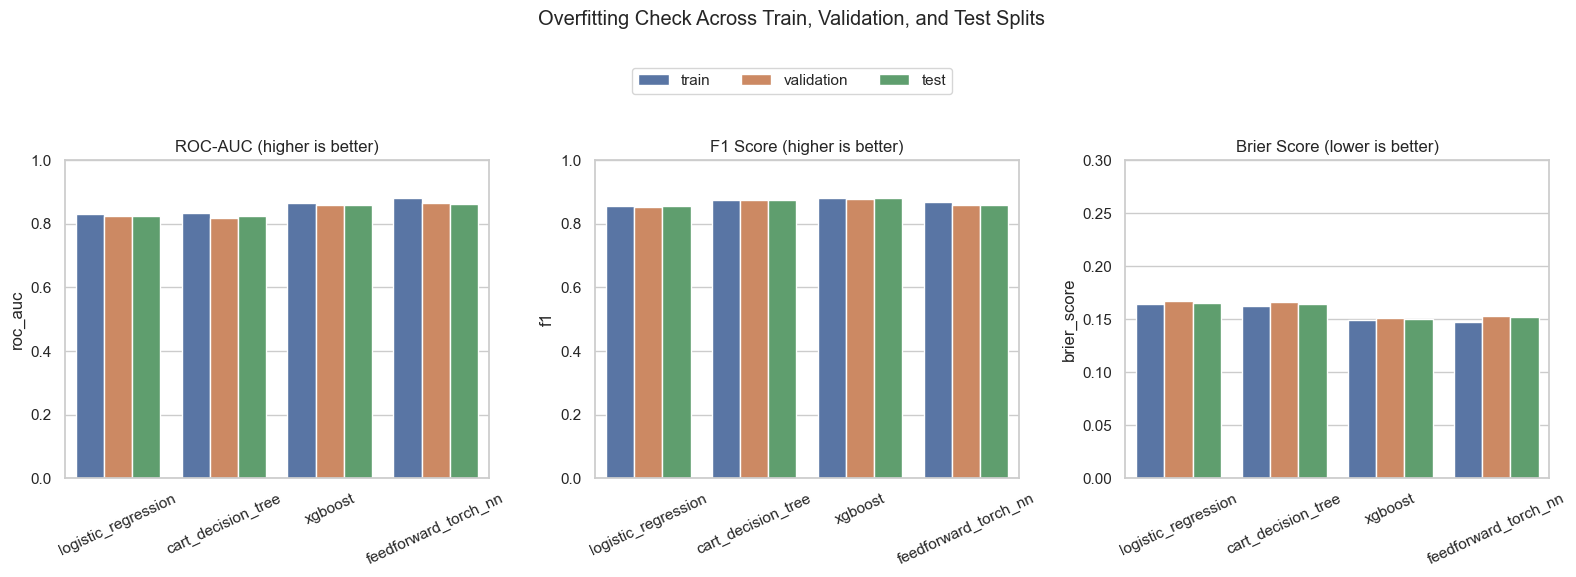

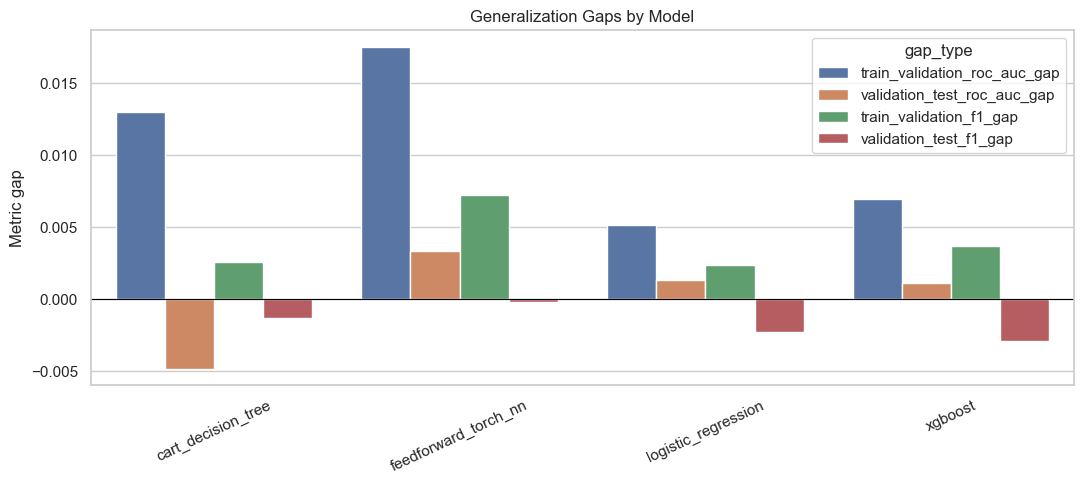

,model,split,roc_auc,balanced_accuracy,f1,mcc,brier_score
0,logistic_regression,train,0.831520,0.750340,0.855197,0.356830,0.164288
1,cart_decision_tree,train,0.832889,0.742400,0.876483,0.363690,0.162704
2,xgboost,train,0.866848,0.779829,0.882034,0.415723,0.149196
3,feedforward_torch_nn,train,0.882838,0.797489,0.867528,0.424139,0.147189
4,logistic_regression,validation,0.826347,0.748257,0.852838,0.352681,0.166887
5,cart_decision_tree,validation,0.819928,0.732707,0.873930,0.349048,0.166265
6,xgboost,validation,0.859902,0.772850,0.878356,0.403479,0.151568
7,feedforward_torch_nn,validation,0.865296,0.781947,0.860268,0.399597,0.153263
8,logistic_regression,test,0.825008,0.747052,0.855096,0.352636,0.164963
9,cart_decision_tree,test,0.824781,0.741501,0.875220,0.361379,0.164593


,model,train_validation_roc_auc_gap,validation_test_roc_auc_gap,train_validation_f1_gap,validation_test_f1_gap,train_validation_brier_score_worsening,validation_test_brier_score_worsening,overfitting_flag
0,cart_decision_tree,0.012961,-0.004854,0.002553,-0.001290,0.003561,-0.001672,Low overfitting risk
1,feedforward_torch_nn,0.017542,0.003364,0.007260,-0.000192,0.006074,-0.000832,Low overfitting risk
2,logistic_regression,0.005173,0.001339,0.002359,-0.002259,0.002599,-0.001924,Low overfitting risk
3,xgboost,0.006946,0.001112,0.003677,-0.002909,0.002372,-0.001287,Low overfitting risk


Best validation PR-AUC iteration: 350
Final train-validation PR-AUC gap: 0.001810933610592369


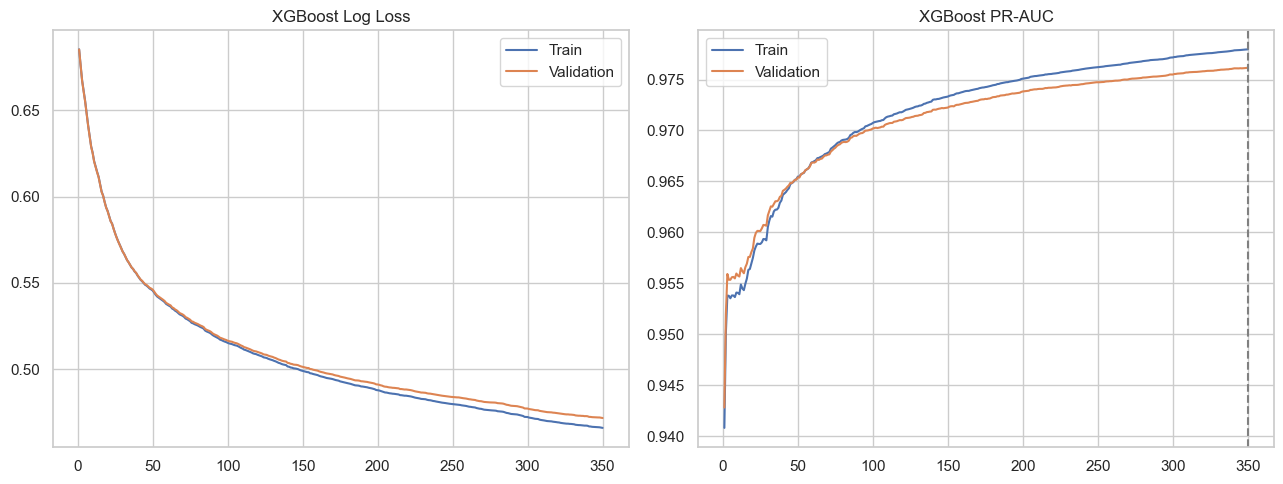

,iteration,train_logloss,valid_logloss,train_aucpr,valid_aucpr
345,346,0.466263,0.471927,0.977906,0.976096
346,347,0.466240,0.471932,0.977920,0.976105
347,348,0.466217,0.471923,0.977938,0.976120
348,349,0.466045,0.471776,0.977949,0.976135
349,350,0.465883,0.471607,0.977962,0.976151


In [7]:
# All-model overfitting check
overfit_metric_rows = []
for split, Xs, ys in [("train", X_train, y_train), ("validation", X_valid, y_valid), ("test", X_test, y_test)]:
    for name, model in models.items():
        proba = predict_proba_positive(model, Xs)
        overfit_metric_rows.append(robust_metrics(name, split, ys, proba, 0.50))

overfit_metrics_df = pd.DataFrame(overfit_metric_rows)
save_table(overfit_metrics_df, paths.tables_dir / "model_metrics_with_train.csv")

overfit_rows = []
for name, g in overfit_metrics_df.groupby("model"):
    g = g.set_index("split")
    row = {"model": name}
    for metric in ["roc_auc", "average_precision_success", "balanced_accuracy", "f1", "mcc", "brier_score"]:
        row[f"train_{metric}"] = g.loc["train", metric]
        row[f"validation_{metric}"] = g.loc["validation", metric]
        row[f"test_{metric}"] = g.loc["test", metric]
        if metric == "brier_score":
            # Higher Brier is worse, so positive means validation/test is worse than the earlier split.
            row[f"train_validation_{metric}_worsening"] = g.loc["validation", metric] - g.loc["train", metric]
            row[f"validation_test_{metric}_worsening"] = g.loc["test", metric] - g.loc["validation", metric]
        else:
            # Higher is better, so positive means the earlier split is better than the later split.
            row[f"train_validation_{metric}_gap"] = g.loc["train", metric] - g.loc["validation", metric]
            row[f"validation_test_{metric}_gap"] = g.loc["validation", metric] - g.loc["test", metric]

    auc_gap = row["train_validation_roc_auc_gap"]
    f1_gap = row["train_validation_f1_gap"]
    brier_worse = row["train_validation_brier_score_worsening"]
    if auc_gap > 0.08 or f1_gap > 0.05 or brier_worse > 0.03:
        flag = "High overfitting risk"
    elif auc_gap > 0.04 or f1_gap > 0.02 or brier_worse > 0.01:
        flag = "Moderate overfitting risk"
    else:
        flag = "Low overfitting risk"
    row["overfitting_flag"] = flag
    overfit_rows.append(row)

overfit_check_df = pd.DataFrame(overfit_rows)
save_table(overfit_check_df, paths.tables_dir / "proposal_overfitting_check_all_models.csv")

# Graph 1: train/validation/test comparison for every model.
plot_metrics = ["roc_auc", "f1", "brier_score"]
metric_titles = {
    "roc_auc": "ROC-AUC (higher is better)",
    "f1": "F1 Score (higher is better)",
    "brier_score": "Brier Score (lower is better)",
}
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=False)
for ax, metric in zip(axes, plot_metrics):
    sns.barplot(data=overfit_metrics_df, x="model", y=metric, hue="split", ax=ax)
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=25)
    if metric == "brier_score":
        ax.set_ylim(0, max(0.30, overfit_metrics_df[metric].max() * 1.15))
    else:
        ax.set_ylim(0, 1)
handles, labels = axes[-1].get_legend_handles_labels()
for ax in axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("Overfitting Check Across Train, Validation, and Test Splits", y=1.15)
plt.tight_layout()
plt.savefig(paths.figures_dir / "proposal_overfitting_check_all_models.png", dpi=180, bbox_inches="tight")
plt.show()

# Graph 2: compact gap view for manuscript discussion.
gap_plot_df = overfit_check_df[[
    "model",
    "train_validation_roc_auc_gap",
    "validation_test_roc_auc_gap",
    "train_validation_f1_gap",
    "validation_test_f1_gap",
]].melt(id_vars="model", var_name="gap_type", value_name="gap")
plt.figure(figsize=(11, 5))
sns.barplot(data=gap_plot_df, x="model", y="gap", hue="gap_type")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Generalization Gaps by Model")
plt.ylabel("Metric gap")
plt.xlabel("")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(paths.figures_dir / "proposal_generalization_gaps_all_models.png", dpi=180)
plt.show()

display(overfit_metrics_df[["model", "split", "roc_auc", "balanced_accuracy", "f1", "mcc", "brier_score"]])
display(overfit_check_df[[
    "model",
    "train_validation_roc_auc_gap",
    "validation_test_roc_auc_gap",
    "train_validation_f1_gap",
    "validation_test_f1_gap",
    "train_validation_brier_score_worsening",
    "validation_test_brier_score_worsening",
    "overfitting_flag",
]])

# XGBoost-specific learning curve
if "xgboost" in models:
    xgb_pipe = models["xgboost"]
    pre = xgb_pipe.named_steps["preprocessor"]
    Xtr = pre.transform(X_train)
    Xva = pre.transform(X_valid)
    xgb_model = xgb_pipe.named_steps["model"]
    curve_params = xgb_model.get_params()
    curve_params["eval_metric"] = ["logloss", "aucpr"]
    curve_model = XGBClassifier(**curve_params)
    curve_model.fit(Xtr, y_train, eval_set=[(Xtr, y_train), (Xva, y_valid)], verbose=False)
    ev = curve_model.evals_result()
    train_key, valid_key = list(ev.keys())[0], list(ev.keys())[1]
    xgb_curve_df = pd.DataFrame({
        "iteration": np.arange(1, len(ev[train_key]["logloss"]) + 1),
        "train_logloss": ev[train_key]["logloss"],
        "valid_logloss": ev[valid_key]["logloss"],
        "train_aucpr": ev[train_key]["aucpr"],
        "valid_aucpr": ev[valid_key]["aucpr"],
    })
    save_table(xgb_curve_df, paths.tables_dir / "proposal_xgboost_learning_curves.csv")
    best_auc_iter = int(xgb_curve_df.loc[xgb_curve_df.valid_aucpr.idxmax(), "iteration"])
    final_gap = float(xgb_curve_df.iloc[-1].train_aucpr - xgb_curve_df.iloc[-1].valid_aucpr)
    print("Best validation PR-AUC iteration:", best_auc_iter)
    print("Final train-validation PR-AUC gap:", final_gap)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(xgb_curve_df.iteration, xgb_curve_df.train_logloss, label="Train")
    axes[0].plot(xgb_curve_df.iteration, xgb_curve_df.valid_logloss, label="Validation")
    axes[0].set_title("XGBoost Log Loss")
    axes[0].legend()
    axes[1].plot(xgb_curve_df.iteration, xgb_curve_df.train_aucpr, label="Train")
    axes[1].plot(xgb_curve_df.iteration, xgb_curve_df.valid_aucpr, label="Validation")
    axes[1].axvline(best_auc_iter, linestyle="--", color="gray")
    axes[1].set_title("XGBoost PR-AUC")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(paths.figures_dir / "proposal_xgboost_learning_curves.png", dpi=180)
    plt.show()
    display(xgb_curve_df.tail())

## 8. ROC and Precision-Recall Curves


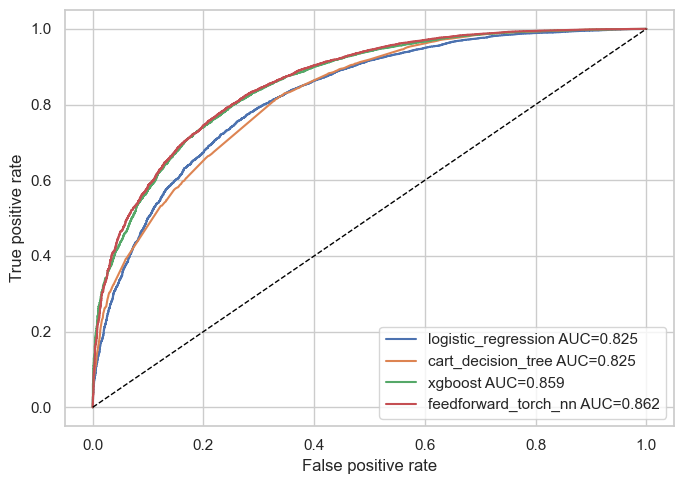

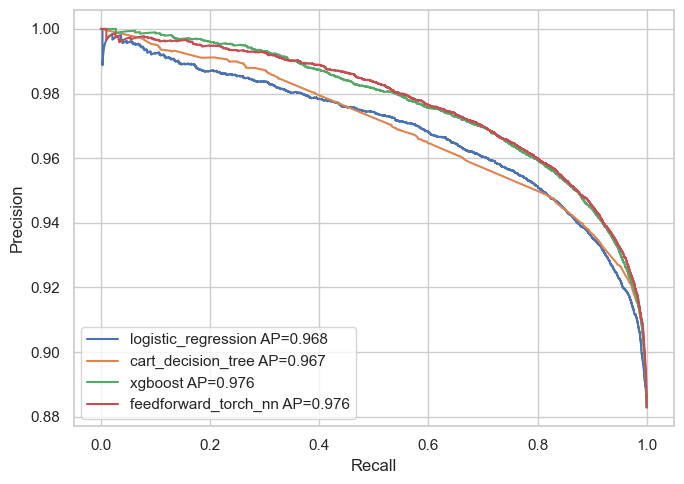

In [8]:
plot_roc_pr_curves(models, X_test, y_test, paths.figures_dir)

## 9. Subgroup Error Disparity Analysis

Algorithmic bias is operationalized as uneven false-positive and false-negative behavior across geopolitical and tactical subgroups. This is model-behavior analysis, not a causal claim about any region or group.


In [9]:
subgroup_columns = ["region_txt", "country_txt", "attacktype1_txt", "targtype1_txt", "weaptype1_txt"]
subgroup_frames = []
for name, model in models.items():
    subgroup_frames.append(subgroup_error_analysis(name, model, X_test, y_test, subgroup_columns, threshold=0.50))
subgroup_df = pd.concat(subgroup_frames, ignore_index=True)
save_table(subgroup_df, paths.tables_dir / "subgroup_error_analysis.csv")

disparity_rows = []
large_groups = subgroup_df[subgroup_df.n >= 200]
for (model_name, subgroup_column), g in large_groups.groupby(["model", "subgroup_column"]):
    disparity_rows.append({
        "model": model_name,
        "subgroup_column": subgroup_column,
        "n_groups": g.group.nunique(),
        "false_positive_rate_gap": g.false_positive_rate.max() - g.false_positive_rate.min(),
        "false_negative_rate_gap": g.false_negative_rate.max() - g.false_negative_rate.min(),
    })
disparity_summary_df = pd.DataFrame(disparity_rows)
save_table(disparity_summary_df, paths.tables_dir / "proposal_subgroup_disparity_summary.csv")

display(subgroup_df.sort_values("false_negative_rate", ascending=False).head(15))
display(disparity_summary_df.sort_values("false_negative_rate_gap", ascending=False))

,model,subgroup_column,group,n,base_success_rate,false_positive_rate,false_negative_rate,tp,fp,tn,fn
98,logistic_regression,targtype1_txt,Unknown,1100,0.350909,0.000000,0.994819,2,0,714,384
204,cart_decision_tree,targtype1_txt,Unknown,1100,0.350909,0.000000,0.898964,39,0,714,347
36,logistic_regression,country_txt,Ireland,56,0.428571,0.000000,0.875000,3,0,32,21
416,feedforward_torch_nn,targtype1_txt,Unknown,1100,0.350909,0.007003,0.844560,60,5,709,326
55,logistic_regression,country_txt,Saudi Arabia,98,0.612245,0.026316,0.816667,11,1,37,49
310,xgboost,targtype1_txt,Unknown,1100,0.350909,0.004202,0.808290,74,3,711,312
354,feedforward_torch_nn,country_txt,Ireland,56,0.428571,0.000000,0.791667,5,0,32,19
37,logistic_regression,country_txt,Israel,344,0.767442,0.150000,0.742424,68,12,68,196
161,cart_decision_tree,country_txt,Saudi Arabia,98,0.612245,0.078947,0.700000,18,3,35,42
174,cart_decision_tree,country_txt,United States,460,0.845652,0.197183,0.696658,118,14,57,271


,model,subgroup_column,n_groups,false_positive_rate_gap,false_negative_rate_gap
13,logistic_regression,targtype1_txt,15,0.673469,0.908535
3,cart_decision_tree,targtype1_txt,15,0.816327,0.838123
18,xgboost,targtype1_txt,15,0.812125,0.756299
8,feedforward_torch_nn,targtype1_txt,15,0.686875,0.746108
11,logistic_regression,country_txt,35,0.781271,0.739270
1,cart_decision_tree,country_txt,35,0.843517,0.674576
10,logistic_regression,attacktype1_txt,6,0.790551,0.667728
15,xgboost,attacktype1_txt,6,0.770143,0.646739
6,feedforward_torch_nn,country_txt,35,0.816753,0.632427
16,xgboost,country_txt,35,0.782216,0.592176


## 10. Interpretability: Logistic Coefficients and XGBoost Feature Importance / SHAP

Logistic coefficients show the linear baseline's global assumptions. XGBoost feature importance or SHAP summarizes nonlinear tree reliance on transformed features.


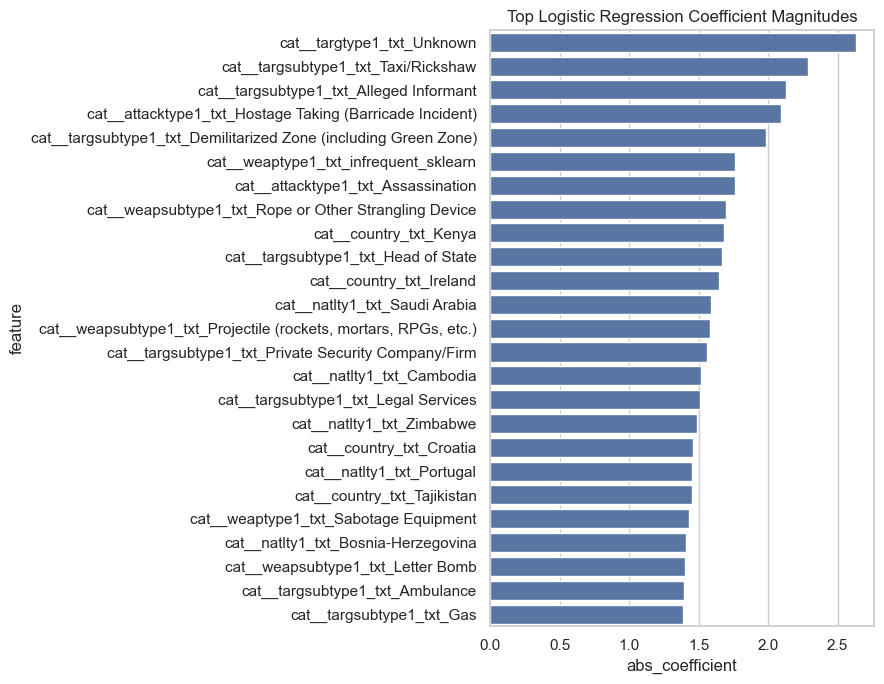

,feature,coefficient,abs_coefficient
194,cat__targtype1_txt_Unknown,-2.629854,2.629854
293,cat__targsubtype1_txt_Taxi/Rickshaw,2.286392,2.286392
201,cat__targsubtype1_txt_Alleged Informant,2.127554,2.127554
171,cat__attacktype1_txt_Hostage Taking (Barricade...,2.092910,2.092910
211,cat__targsubtype1_txt_Demilitarized Zone (incl...,1.987466,1.987466
462,cat__weaptype1_txt_infrequent_sklearn,-1.762991,1.762991
167,cat__attacktype1_txt_Assassination,-1.760884,1.760884
484,cat__weapsubtype1_txt_Rope or Other Strangling...,1.700229,1.700229
92,cat__country_txt_Kenya,-1.682147,1.682147
226,cat__targsubtype1_txt_Head of State,-1.666422,1.666422


c:\Users\Paulo Tumabing\.conda\envs\ml-course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


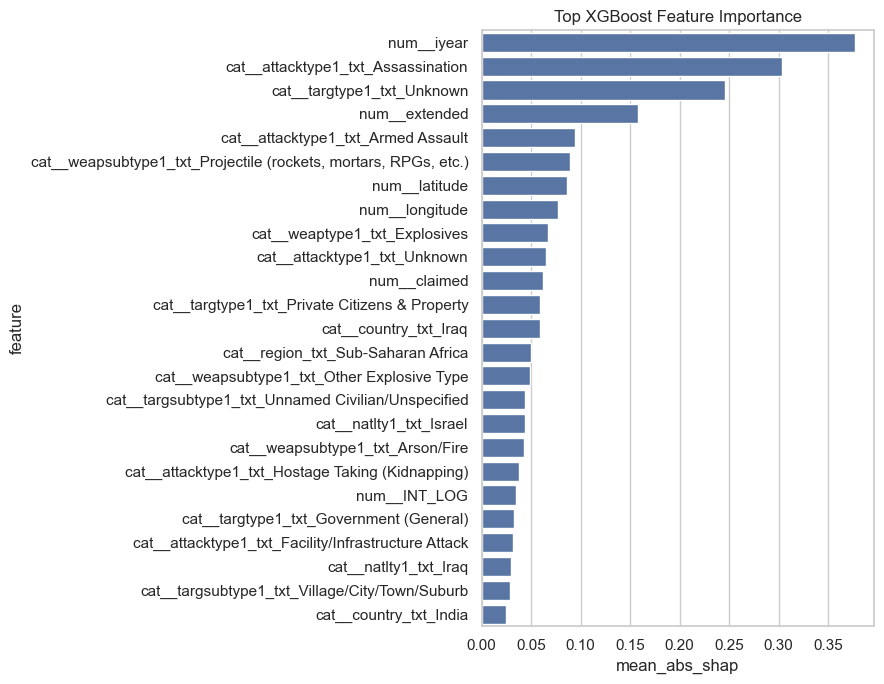

,feature,mean_abs_shap
0,num__iyear,0.377517
167,cat__attacktype1_txt_Assassination,0.303602
194,cat__targtype1_txt_Unknown,0.245552
3,num__extended,0.158511
166,cat__attacktype1_txt_Armed Assault,0.094905
481,"cat__weapsubtype1_txt_Projectile (rockets, mor...",0.089635
4,num__latitude,0.086013
5,num__longitude,0.077729
453,cat__weaptype1_txt_Explosives,0.067511
174,cat__attacktype1_txt_Unknown,0.065608


In [10]:
def feature_names(pipeline):
    return list(pipeline.named_steps["preprocessor"].get_feature_names_out())

if "logistic_regression" in models:
    lr = models["logistic_regression"]
    lr_importance = pd.DataFrame({
        "feature": feature_names(lr),
        "coefficient": lr.named_steps["model"].coef_.ravel(),
    })
    lr_importance["abs_coefficient"] = lr_importance.coefficient.abs()
    lr_importance = lr_importance.sort_values("abs_coefficient", ascending=False).head(25)
    save_table(lr_importance, paths.tables_dir / "proposal_logistic_coefficients.csv")
    plt.figure(figsize=(9, 7))
    sns.barplot(data=lr_importance, x="abs_coefficient", y="feature")
    plt.title("Top Logistic Regression Coefficient Magnitudes")
    plt.tight_layout()
    plt.savefig(paths.figures_dir / "importance_logistic_regression.png", dpi=180)
    plt.show()
    display(lr_importance)

if "xgboost" in models:
    xgb = models["xgboost"]
    features = feature_names(xgb)
    xgb_model = xgb.named_steps["model"]
    if RUN_SHAP:
        try:
            import shap
            sample = X_test.sample(min(len(X_test), SHAP_SAMPLE_SIZE), random_state=RANDOM_STATE)
            transformed = xgb.named_steps["preprocessor"].transform(sample)
            shap_values = shap.TreeExplainer(xgb_model).shap_values(transformed)
            xgb_importance = pd.DataFrame({"feature": features, "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
            x_axis = "mean_abs_shap"
        except Exception as exc:
            print("SHAP unavailable/failed; using built-in importance:", exc)
            xgb_importance = pd.DataFrame({"feature": features, "importance": xgb_model.feature_importances_})
            x_axis = "importance"
    else:
        xgb_importance = pd.DataFrame({"feature": features, "importance": xgb_model.feature_importances_})
        x_axis = "importance"
    xgb_importance = xgb_importance.sort_values(x_axis, ascending=False).head(25)
    save_table(xgb_importance, paths.tables_dir / "proposal_xgboost_importance.csv")
    plt.figure(figsize=(9, 7))
    sns.barplot(data=xgb_importance, x=x_axis, y="feature")
    plt.title("Top XGBoost Feature Importance")
    plt.tight_layout()
    plt.savefig(paths.figures_dir / "importance_xgboost.png", dpi=180)
    plt.show()
    display(xgb_importance)

## 11. Robustness Checks: Strict Features and Feature-Group Ablations

Strict-feature analysis removes potentially coding-time variables. Feature-group ablations show whether XGBoost depends more on geography, time, or tactical variables.


In [11]:
STRICT_DROP = ["extended", "claimed", "doubtterr"]
FEATURE_GROUPS_TO_DROP = {
    "drop_geography": ["region_txt", "country_txt", "latitude", "longitude", "natlty1_txt"],
    "drop_time": ["iyear", "imonth", "iday"],
    "drop_tactical_attack_target_weapon": ["attacktype1_txt", "targtype1_txt", "targsubtype1_txt", "weaptype1_txt", "weapsubtype1_txt"],
    "drop_uncertainty_claim": ["doubtterr", "guncertain1", "claimed"],
}

def train_xgb_with_drops(label, drop_cols):
    keep_numeric = [c for c in numeric_features if c not in drop_cols]
    keep_categorical = [c for c in categorical_features if c not in drop_cols]
    keep = keep_numeric + keep_categorical
    pos, neg = max(int((y_train == 1).sum()), 1), max(int((y_train == 0).sum()), 1)
    model = Pipeline([
        ("preprocessor", make_preprocessor(keep_numeric, keep_categorical)),
        ("model", XGBClassifier(
            n_estimators=350, max_depth=4, learning_rate=0.05, subsample=0.85,
            colsample_bytree=0.85, objective="binary:logistic", eval_metric="logloss",
            scale_pos_weight=neg / pos, random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
        )),
    ])
    model.fit(X_train[keep], y_train)
    rows = []
    for split, Xs, ys in [("validation", X_valid[keep], y_valid), ("test", X_test[keep], y_test)]:
        rows.append(robust_metrics(label, split, ys, predict_proba_positive(model, Xs), 0.50))
    return rows

strict_rows = train_xgb_with_drops("strict_xgboost", STRICT_DROP)
strict_df = pd.DataFrame(strict_rows)
strict_df["dropped_columns"] = ", ".join(STRICT_DROP)
save_table(strict_df, paths.tables_dir / "proposal_strict_feature_audit.csv")

ablation_rows = []
for split, Xs, ys in [("validation", X_valid, y_valid), ("test", X_test, y_test)]:
    ablation_rows.append(robust_metrics("xgboost_full_feature_set", split, ys, predict_proba_positive(models["xgboost"], Xs), 0.50))
for label, drops in FEATURE_GROUPS_TO_DROP.items():
    print("Running ablation:", label)
    ablation_rows.extend(train_xgb_with_drops(f"xgboost_{label}", drops))
ablation_df = pd.DataFrame(ablation_rows)
save_table(ablation_df, paths.tables_dir / "proposal_feature_group_ablation.csv")

display(strict_df)
display(ablation_df.sort_values(["split", "roc_auc"], ascending=[True, False]))

Running ablation: drop_geography
Running ablation: drop_time
Running ablation: drop_tactical_attack_target_weapon
Running ablation: drop_uncertainty_claim


,model,split,roc_auc,average_precision_success,average_precision_failure,brier_score,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,mcc,dropped_columns
0,strict_xgboost,validation,0.853644,0.973726,0.537857,0.152205,0.5,0.800652,0.769111,0.957360,0.810299,0.877712,0.272076,0.189701,23036,1026,2745,5393,0.398242,"extended, claimed, doubtterr"
1,strict_xgboost,test,0.853586,0.974377,0.537913,0.150980,0.5,0.803758,0.768225,0.956667,0.814626,0.879951,0.278176,0.185374,23159,1049,2722,5270,0.399330,"extended, claimed, doubtterr"


,model,split,roc_auc,average_precision_success,average_precision_failure,brier_score,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,mcc
1,xgboost_full_feature_set,test,0.858790,0.976252,0.542189,0.150281,0.5,0.805776,0.771093,0.957349,0.816385,0.881265,0.274198,0.183615,23209,1034,2737,5220,0.404194
9,xgboost_drop_uncertainty_claim,test,0.857407,0.975978,0.537702,0.151239,0.5,0.802795,0.770900,0.957672,0.812551,0.879163,0.270750,0.187449,23100,1021,2750,5329,0.401857
5,xgboost_drop_time,test,0.845549,0.973629,0.515666,0.157544,0.5,0.795404,0.758779,0.954623,0.806606,0.874395,0.289048,0.193394,22931,1090,2681,5498,0.382316
3,xgboost_drop_geography,test,0.837058,0.971376,0.510305,0.158484,0.5,0.802391,0.751236,0.951321,0.818038,0.879660,0.315566,0.181962,23256,1190,2581,5173,0.377880
7,xgboost_drop_tactical_attack_target_weapon,test,0.748932,0.953976,0.334727,0.202412,0.5,0.677391,0.673430,0.939103,0.678603,0.787879,0.331742,0.321397,19292,1251,2520,9137,0.232081
0,xgboost_full_feature_set,validation,0.859902,0.976152,0.542377,0.151568,0.5,0.801770,0.772850,0.958451,0.810616,0.878356,0.264916,0.189384,23045,999,2772,5384,0.403479
8,xgboost_drop_uncertainty_claim,validation,0.857731,0.975767,0.538656,0.152525,0.5,0.800901,0.772242,0.958365,0.809666,0.877762,0.265182,0.190334,23018,1000,2771,5411,0.402158
4,xgboost_drop_time,validation,0.843696,0.973030,0.512000,0.158941,0.5,0.791149,0.756369,0.954363,0.801787,0.871447,0.289048,0.198213,22794,1090,2681,5635,0.376699
2,xgboost_drop_geography,validation,0.834629,0.971046,0.508508,0.160699,0.5,0.796366,0.748514,0.951155,0.811003,0.875506,0.313975,0.188997,23056,1184,2587,5373,0.370482
6,xgboost_drop_tactical_attack_target_weapon,validation,0.762858,0.956963,0.346310,0.202039,0.5,0.681739,0.691533,0.945373,0.678744,0.790172,0.295678,0.321256,19296,1115,2656,9133,0.255689


## 12. Bootstrap Confidence Intervals and Calibration

Confidence intervals quantify uncertainty. Calibration curves test whether model scores are meaningful for threshold-based decisions.


,model,metric,point_estimate,ci_lower_95,ci_upper_95
0,logistic_regression,roc_auc,0.825008,0.817449,0.831785
1,logistic_regression,average_precision_success,0.968330,0.966327,0.970385
2,logistic_regression,average_precision_failure,0.466310,0.449572,0.483295
3,logistic_regression,balanced_accuracy,0.747052,0.739685,0.754209
4,logistic_regression,mcc,0.352636,0.340724,0.361910
5,cart_decision_tree,roc_auc,0.824781,0.817110,0.832638
6,cart_decision_tree,average_precision_success,0.967108,0.965216,0.969349
7,cart_decision_tree,average_precision_failure,0.496308,0.479915,0.513609
8,cart_decision_tree,balanced_accuracy,0.741501,0.733891,0.750448
9,cart_decision_tree,mcc,0.361379,0.349797,0.373337


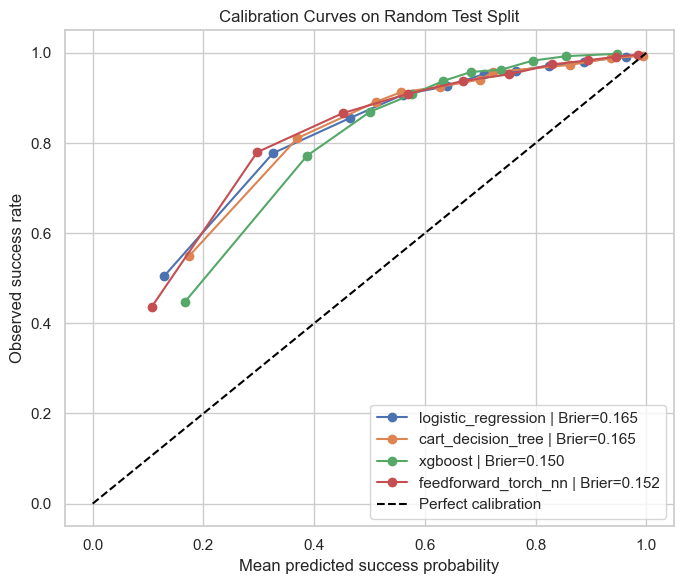

,model,bin,mean_predicted_probability,observed_success_rate,brier_score
0,logistic_regression,1,0.129395,0.505280,0.164963
1,logistic_regression,2,0.325740,0.777640,0.164963
2,logistic_regression,3,0.464214,0.855280,0.164963
3,logistic_regression,4,0.561338,0.907764,0.164963
4,logistic_regression,5,0.639340,0.926087,0.164963
5,logistic_regression,6,0.706101,0.952795,0.164963
6,logistic_regression,7,0.763829,0.959938,0.164963
7,logistic_regression,8,0.823405,0.971739,0.164963
8,logistic_regression,9,0.887700,0.980435,0.164963
9,logistic_regression,10,0.963930,0.991925,0.164963


In [12]:
from sklearn.calibration import calibration_curve

N_BOOTSTRAP = 300
rng = np.random.default_rng(RANDOM_STATE)

def bootstrap_ci(name, y_true, proba, threshold=0.50):
    y_arr, p_arr = np.asarray(y_true), np.asarray(proba)
    rows = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, len(y_arr), len(y_arr))
        if len(np.unique(y_arr[idx])) < 2:
            continue
        rows.append(robust_metrics(name, "bootstrap", y_arr[idx], p_arr[idx], threshold))
    boot = pd.DataFrame(rows)
    point = robust_metrics(name, "test", y_arr, p_arr, threshold)
    metrics = ["roc_auc", "average_precision_success", "average_precision_failure", "balanced_accuracy", "mcc"]
    return pd.DataFrame([{
        "model": name,
        "metric": m,
        "point_estimate": point[m],
        "ci_lower_95": boot[m].quantile(0.025),
        "ci_upper_95": boot[m].quantile(0.975),
    } for m in metrics])

ci_df = pd.concat([bootstrap_ci(name, y_test, predict_proba_positive(model, X_test)) for name, model in models.items()], ignore_index=True)
save_table(ci_df, paths.tables_dir / "proposal_bootstrap_confidence_intervals.csv")
display(ci_df)

calibration_rows = []
plt.figure(figsize=(7, 6))
for name, model in models.items():
    proba = predict_proba_positive(model, X_test)
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    brier = brier_score_loss(y_test, proba)
    for i, (mp, fp) in enumerate(zip(mean_pred, frac_pos), 1):
        calibration_rows.append({"model": name, "bin": i, "mean_predicted_probability": mp, "observed_success_rate": fp, "brier_score": brier})
    plt.plot(mean_pred, frac_pos, marker="o", label=f"{name} | Brier={brier:.3f}")
plt.plot([0, 1], [0, 1], "--", color="black", label="Perfect calibration")
plt.xlabel("Mean predicted success probability")
plt.ylabel("Observed success rate")
plt.title("Calibration Curves on Random Test Split")
plt.legend()
plt.tight_layout()
plt.savefig(paths.figures_dir / "proposal_calibration_curves.png", dpi=180)
plt.show()
calibration_df = pd.DataFrame(calibration_rows)
save_table(calibration_df, paths.tables_dir / "proposal_calibration_curves.csv")
display(calibration_df)

## 13. Random-Split Summary

This notebook saves models, figures, and tables for the random-split comparison only. The outputs are written under `models/random_split/`, `results/figures/random_split/`, and `results/tables/random_split/` so the main temporal-split outputs remain unchanged.


In [13]:
important_tables = [
    "model_metrics.csv",
    "model_metrics_with_train.csv",
    "proposal_validation_selected_thresholds.csv",
    "threshold_simulation_results.csv",
    "subgroup_error_analysis.csv",
    "proposal_subgroup_disparity_summary.csv",
    "proposal_xgboost_importance.csv",
    "proposal_logistic_coefficients.csv",
    "proposal_strict_feature_audit.csv",
    "proposal_feature_group_ablation.csv",
    "proposal_bootstrap_confidence_intervals.csv",
    "proposal_calibration_curves.csv",
    "proposal_overfitting_check_all_models.csv",
]
print("Saved models to:", paths.models_dir)
print("Saved figures to:", paths.figures_dir)
print("Saved tables to:", paths.tables_dir)
for table in important_tables:
    print(" -", paths.tables_dir / table)
print("Random-split notebook complete. Compare these outputs against the main temporal-split run.")

Saved models to: c:\Documents\Compsci\CSELEC2C\Project\models\random_split
Saved figures to: c:\Documents\Compsci\CSELEC2C\Project\results\figures\random_split
Saved tables to: c:\Documents\Compsci\CSELEC2C\Project\results\tables\random_split
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\random_split\model_metrics.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\random_split\model_metrics_with_train.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\random_split\proposal_validation_selected_thresholds.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\random_split\threshold_simulation_results.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\random_split\subgroup_error_analysis.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\random_split\proposal_subgroup_disparity_summary.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\random_split\proposal_xgboost_importance.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\t